# Indian Stock Market Analysis and Trend Visualization

## Project Overview:

This project analyzes historical stock data of major Indian companies (Reliance, TCS, HDFC Bank, Infosys) over the last 2 years. The aim is to visualize trends, calculate moving averages, study correlations, and measure volatility to provide actionable insights for investors. Python, Pandas, NumPy, Matplotlib, and Seaborn were used for data handling, analysis, and visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# Indian NSE tickers
tickers = ["RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "INFY.NS"]

# Download data
data = yf.download(tickers, start="2022-01-01", end="2025-01-01")

# Check what columns are available
print("Columns:", data.columns)

# Handle multi-index columns for multiple tickers
if isinstance(data.columns, pd.MultiIndex):
    if 'Adj Close' in data.columns.levels[0]:
        adj_close = data['Adj Close']
    else:
        adj_close = data['Close']
else:
    # Single ticker case
    adj_close = data['Adj Close'] if 'Adj Close' in data.columns else data['Close']

print(adj_close.head())


C:\Users\rkman\AppData\Local\Temp\ipykernel_68472\1771947022.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2022-01-01", end="2025-01-01")
[*********************100%***********************]  4 of 4 completed

Columns: MultiIndex([( 'Close', 'HDFCBANK.NS'),
            ( 'Close',     'INFY.NS'),
            ( 'Close', 'RELIANCE.NS'),
            ( 'Close',      'TCS.NS'),
            (  'High', 'HDFCBANK.NS'),
            (  'High',     'INFY.NS'),
            (  'High', 'RELIANCE.NS'),
            (  'High',      'TCS.NS'),
            (   'Low', 'HDFCBANK.NS'),
            (   'Low',     'INFY.NS'),
            (   'Low', 'RELIANCE.NS'),
            (   'Low',      'TCS.NS'),
            (  'Open', 'HDFCBANK.NS'),
            (  'Open',     'INFY.NS'),
            (  'Open', 'RELIANCE.NS'),
            (  'Open',      'TCS.NS'),
            ('Volume', 'HDFCBANK.NS'),
            ('Volume',     'INFY.NS'),
            ('Volume', 'RELIANCE.NS'),
            ('Volume',      'TCS.NS')],
           names=['Price', 'Ticker'])
Ticker      HDFCBANK.NS      INFY.NS  RELIANCE.NS       TCS.NS
Date                                                          
2022-01-03   722.802551  1704.249390  1093.780

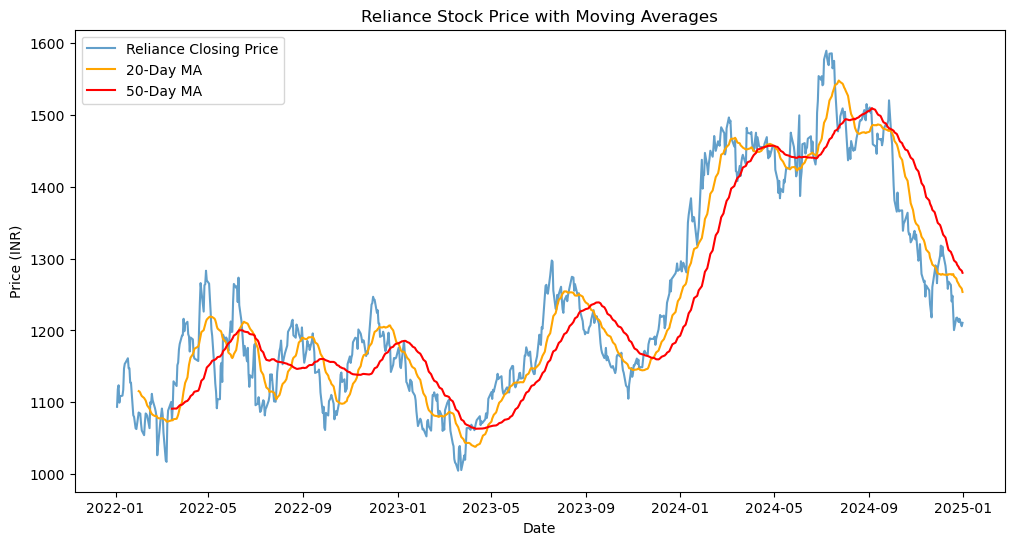

In [2]:
# Reliance stock
reliance = adj_close["RELIANCE.NS"]

# Moving average function
def moving_average(values, window):
    return np.convolve(values, np.ones(window)/window, mode='valid')

ma20 = moving_average(reliance.values, 20)
ma50 = moving_average(reliance.values,50)

# Plot
plt.figure(figsize=(12,6))
plt.plot(reliance.index, reliance, label="Reliance Closing Price", alpha=0.7)
plt.plot(reliance.index[19:], ma20, label="20-Day MA", color="orange")
plt.plot(reliance.index[49:], ma50, label="50-Day MA", color="red")
plt.title("Reliance Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.legend()
plt.show()

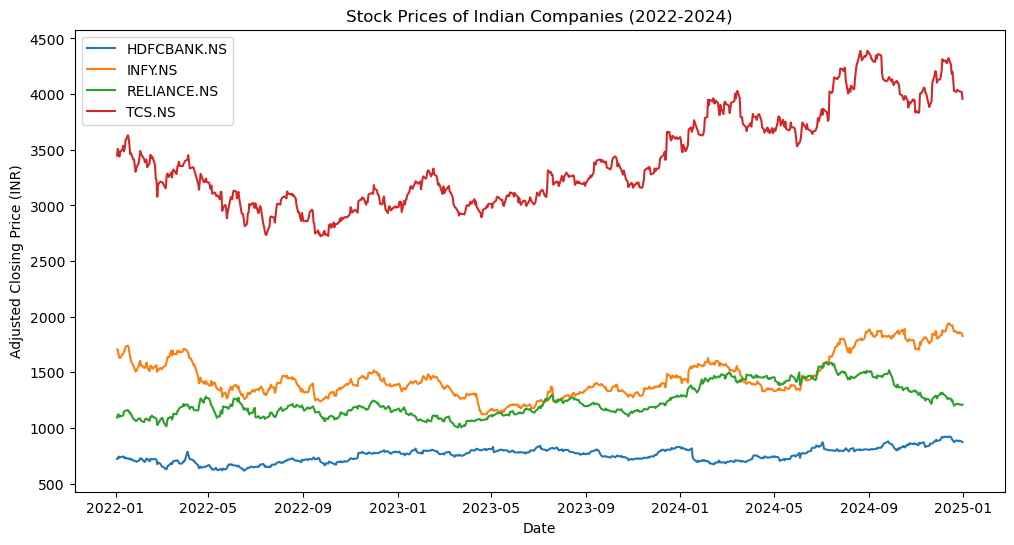

In [3]:
plt.figure(figsize=(12,6))

for ticker in adj_close.columns:
    plt.plot(adj_close.index, adj_close[ticker], label=ticker)

plt.title("Stock Prices of Indian Companies (2022-2024)")
plt.xlabel("Date")
plt.ylabel("Adjusted Closing Price (INR)")
plt.legend()
plt.show()


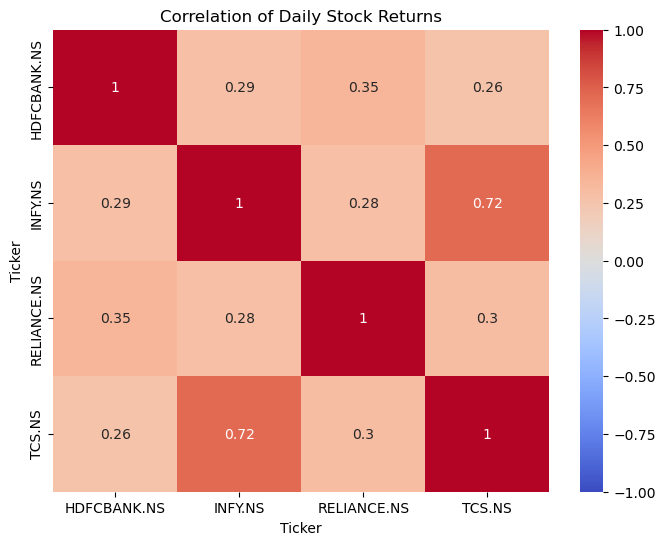

In [4]:
# Calculate daily returns
returns = adj_close.pct_change().dropna()

# Correlation matrix
corr = returns.corr()

# Plot correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation of Daily Stock Returns")
plt.show()


Annualized Volatility of Stocks:
Ticker
HDFCBANK.NS    0.218745
INFY.NS        0.247260
RELIANCE.NS    0.226066
TCS.NS         0.209423
dtype: float64


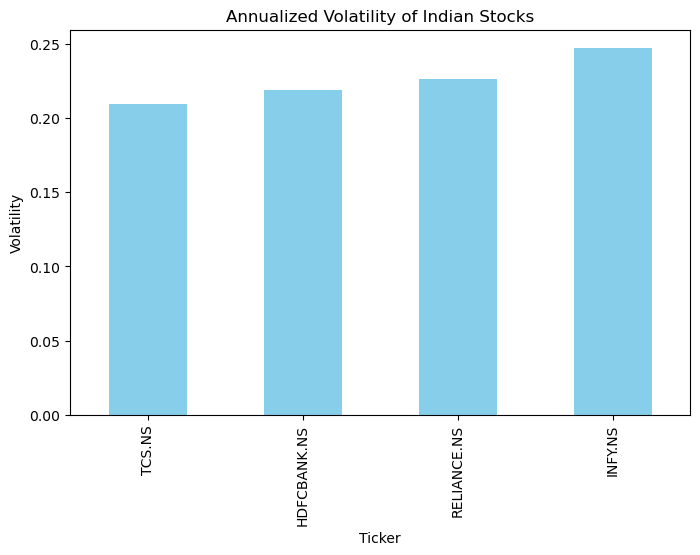

In [5]:
# Annualized volatility approximation
volatility = returns.std() * np.sqrt(252)  # 252 trading days
print("Annualized Volatility of Stocks:")
print(volatility)

# Plot volatility
plt.figure(figsize=(8,5))
volatility.sort_values().plot(kind='bar', color='skyblue')
plt.title("Annualized Volatility of Indian Stocks")
plt.ylabel("Volatility")
plt.show()


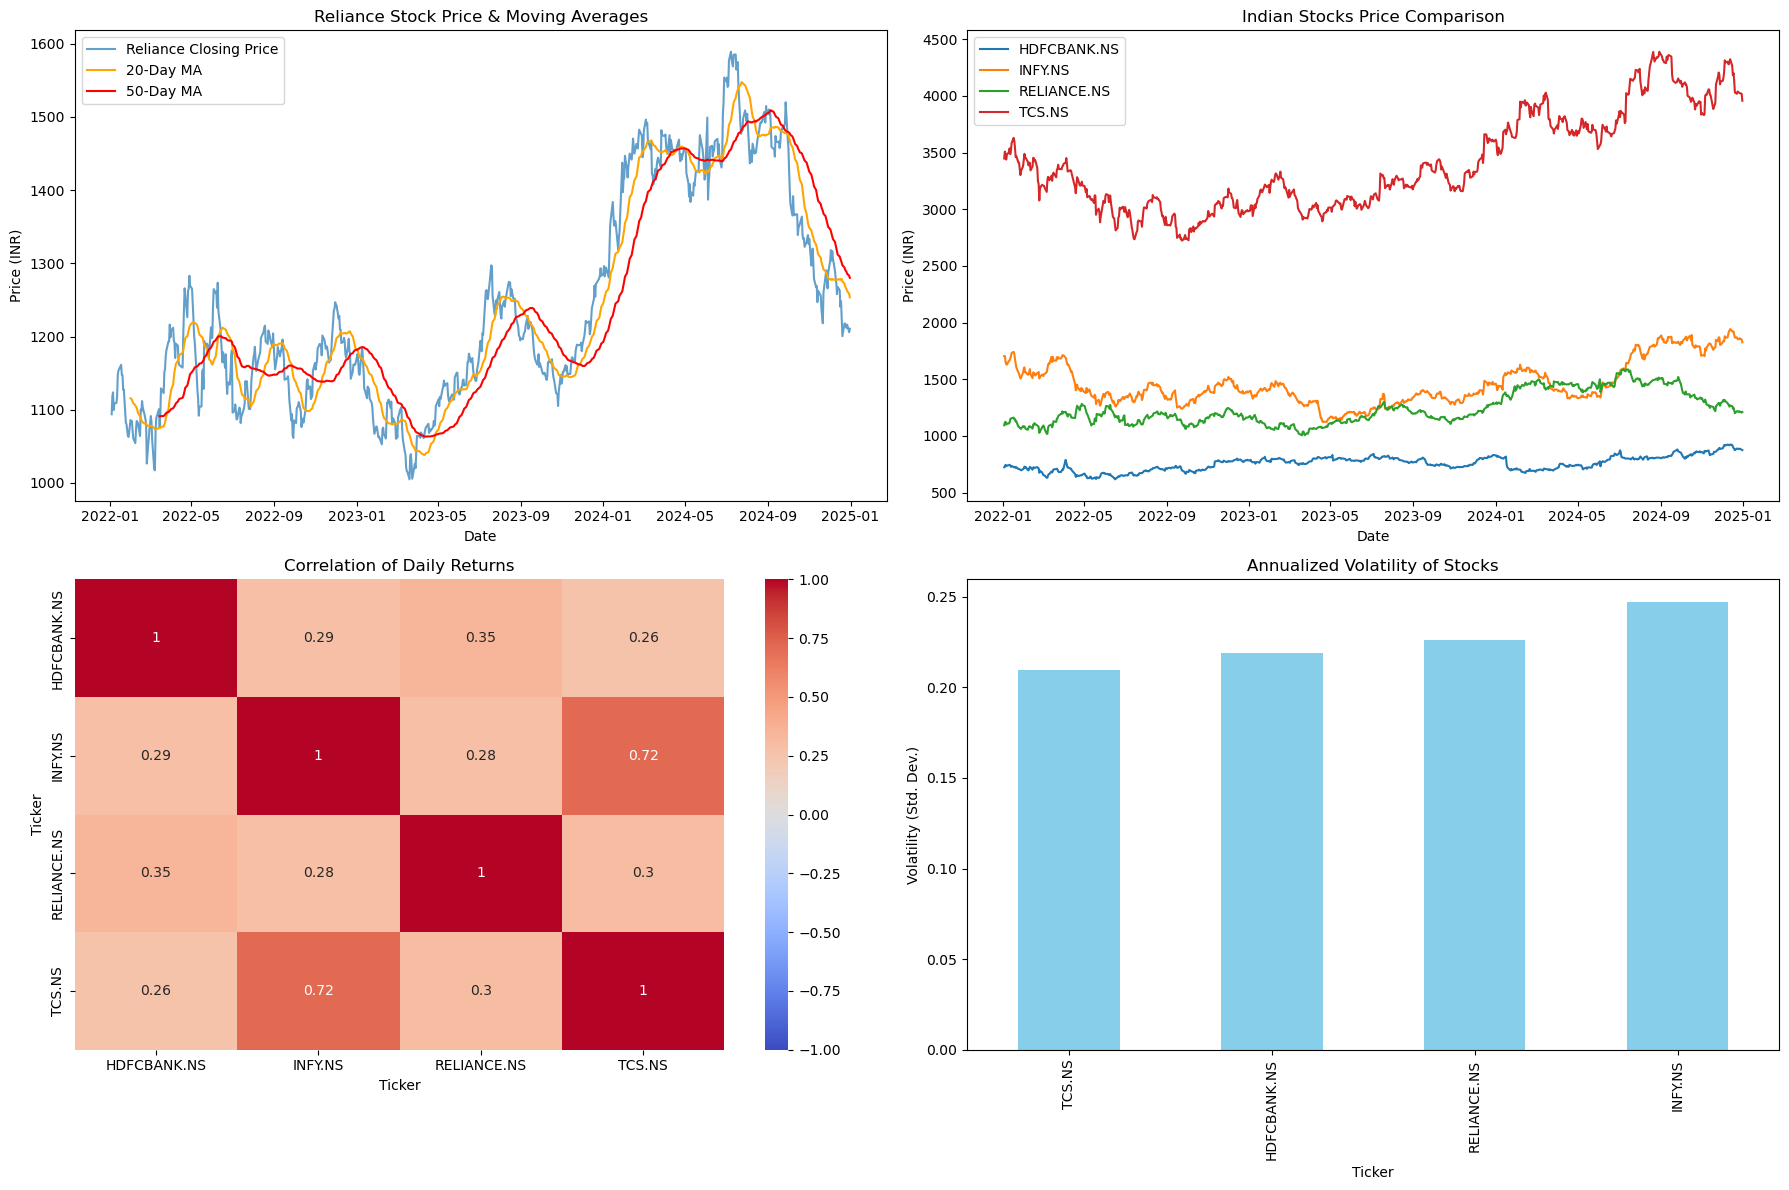

In [6]:
# Step 6: Final Summary Dashboard
plt.figure(figsize=(18,12))

# 1️⃣ Stock Prices with Moving Averages (Reliance)
plt.subplot(2,2,1)
plt.plot(reliance.index, reliance, label="Reliance Closing Price", alpha=0.7)
plt.plot(reliance.index[19:], ma20, label="20-Day MA", color="orange")
plt.plot(reliance.index[49:], ma50, label="50-Day MA", color="red")
plt.title("Reliance Stock Price & Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.legend()

# 2️⃣ Multi-stock Comparison
plt.subplot(2,2,2)
for ticker in adj_close.columns:
    plt.plot(adj_close.index, adj_close[ticker], label=ticker)
plt.title("Indian Stocks Price Comparison")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.legend()

# 3️⃣ Correlation Heatmap
plt.subplot(2,2,3)
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation of Daily Returns")

# 4️⃣ Volatility Bar Chart
plt.subplot(2,2,4)
volatility.sort_values().plot(kind='bar', color='skyblue')
plt.title("Annualized Volatility of Stocks")
plt.ylabel("Volatility (Std. Dev.)")

plt.tight_layout()
plt.show()
